# **EXPERIMENT-8** -MNIST Dataset

**AIM:** To implement and demonstrate the working of a Multi-Layer Perceptron (MLP) using MLPClassifier() from the scikit-learn library in Python to classify handwritten digits from the MNIST dataset.

**Algorithm Description – Multi-Layer Perceptron (MLP)**

A Multi-Layer Perceptron (MLP) is a type of Artificial Neural Network (ANN) used for solving classification and regression problems.
* It consists of multiple layers of neurons that are fully connected.
* It learns patterns in data by passing inputs through multiple layers of neurons where each neuron performs a weighted calculation followed by an activation function.

**Architecture of MLP:**
An MLP contains three main layers:
 1. Input Layer
    * Receives the input features.Each feature is given to one neuron.
    * In this experiment, each image is flattened into 784 pixels (28×28).
 2. Hidden Layers
   * Hidden layers perform computations on the input data using weights and activation functions.
   * Applies Activation functions such as ReLU, tanh, or logistic introduce non-linearity.
 3. Output Layer
  * Produces the final prediction.
  * Uses softmax internally for multi-class classification.

**Mathematical Representation:**

Each neuron computes:

        𝑧=𝑤^T𝑥+𝑏
        𝑎=f(𝑧)

Where:
  * x → input features
  * w → weights
  * b → bias
  * f(z) → activation function



**Training an MLP involves the following steps:**

  1. Forward Propagation
     * Forward propagation is the process where input data passes through the neural network layer by layer. Each neuron calculates the weighted sum and applies the activation function to produce an output.
     * The final output from the last layer becomes the predicted value.
  2. Loss Calculation
     * The loss function measures the difference between the predicted output and the actual label. A common loss function for classification is cross-entropy loss.

     Example loss formula:

         Loss = -sum(y * log(y_pred))

     * A smaller loss value means the model predictions are closer to the true labels.    
  3. Backpropagation
     * Backpropagation calculates how much each weight contributed to the prediction error. The error is propagated backward through the network to compute gradients.
     * These gradients are used to determine how the weights should be adjusted.
  4. Weight Update
     * After calculating gradients during backpropagation, the optimizer adjusts the weights in the direction that reduces the loss. This process repeats for many iterations until the model learns the patterns/model reaches the best weights.

     General update rule:
     
           new_weight = old_weight - learning_rate * gradient


    
**Activation Functions:**

* Activation functions are mathematical functions used in neural networks to introduce non-linearity, which allows the network to learn complex patterns in the data.
* Without activation functions, the neural network would behave like a simple linear model and would not be able to learn complex relationships.


**Types of Activation Functions:**

 1. **ReLU (Rectified Linear Unit)**

The ReLU activation function outputs the input value if it is positive, and outputs zero if the input value is negative. The formula is:

         f(x)=max(0,x)

ReLU is widely used in deep learning because it is simple, computationally efficient, and helps avoid the vanishing gradient problem during training.

 2. **Sigmoid Function**
The sigmoid activation function converts any input value into a number between 0 and 1, which can be interpreted as a probability. The formula is:

         f(x) = 1 / (1 + e^(-x))



Sigmoid is commonly used in binary classification problems where the model must decide between two classes, such as yes or no, or true or false.

 3. **Tanh Function**

The tanh function is similar to sigmoid but its output ranges from negative to positive values, making it centered around zero.

     tanh(x) = (e^x - e^(-x)) / (e^x + e^(-x))

Tanh is often used in hidden layers because it allows the model to learn both positive and negative relationships in the data.



**Gradient:**

A gradient represents the rate of change of the loss function with respect to the model parameters (weights). It tells the model how much the weights should change to reduce prediction error.

* During training, gradients are calculated to update the weights so that the loss becomes smaller.


      gradient = derivative of loss with respect to weight

If the gradient is large, the weight is updated more; if it is small, the weight changes slightly.

**Dataset Description – MNIST:**

The MNIST (Modified National Institute of Standards and Technology) dataset is a widely used dataset for handwritten digit recognition.

| Property         | Description     |
| ---------------- | --------------- |
| Training Samples | 60,000          |
| Testing Samples  | 10,000          |
| Image Size       | 28 × 28 pixels  |
| Pixel Type       | Grayscale       |
| Classes          | 10 digits (0–9) |


Each image represents a handwritten digit.

Before feeding into the neural network, the image is flattened into a vector of 784 features.

**Step 1 – Import Required Libraries**

MLPClassifier is the implementation of the Multi-Layer Perceptron algorithm used for classification tasks in the scikit-learn library.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

**Load Dataset**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
X_train = np.load('/content/drive/MyDrive/Datasets/MNIST Handwritten Digits/MNIST Handwritten Digits/train_images.npy')
Y_train = np.load('/content/drive/MyDrive/Datasets/MNIST Handwritten Digits/MNIST Handwritten Digits/train_labels.npy')
X_test = np.load('/content/drive/MyDrive/Datasets/MNIST Handwritten Digits/MNIST Handwritten Digits/test_images.npy')
Y_test = np.load('/content/drive/MyDrive/Datasets/MNIST Handwritten Digits/MNIST Handwritten Digits/test_labels.npy')

print("Train Shape:", X_train.shape)
print("Test Shape:", X_test.shape)
print("Unique Classes:", np.unique(Y_train))

Train Shape: (60000, 28, 28)
Test Shape: (10000, 28, 28)
Unique Classes: [0 1 2 3 4 5 6 7 8 9]


**Step 4 – Visualizing Sample Images:**

 * A few training images are displayed using Matplotlib.
 * This helps in understanding:
   * How the handwritten digits look
   * Corresponding labels for each image
 * Each image is displayed with its actual digit label.

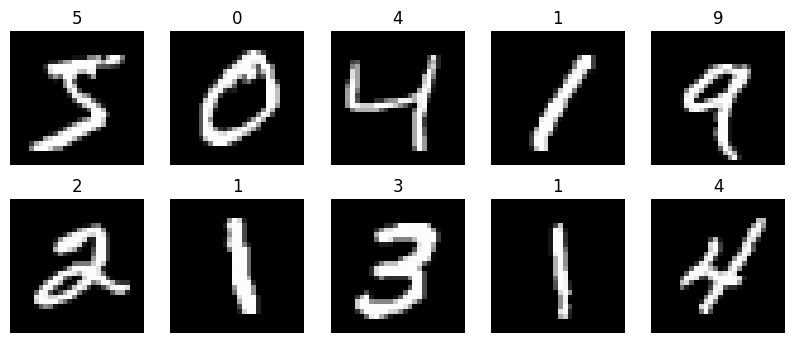

In [ ]:
plt.figure(figsize=(10,4))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X_train[i], cmap='gray')
    plt.title(Y_train[i])
    plt.axis('off')
plt.show()

**Step 5 – Data Preprocessing:**


**1. Flattening Images**

MLP requires input data in 2D format.
Since images are 28×28, they are reshaped into:

    784=28×28

So each image becomes a 784-dimensional feature vector.

In [ ]:
X_train = X_train.reshape(X_train.shape[0], -1)
X_test = X_test.reshape(X_test.shape[0], -1)
print("After Flattening:", X_train.shape)

After Flattening: (60000, 784)


**2. Normalization**

Pixel values range from 0 to 255.
They are scaled to 0–1 range by dividing by 255.
* Benefits of normalization:
  * Faster convergence
  * Improved numerical stability
  * Better neural network performance

In [ ]:
X_train = X_train / 255.0
X_test = X_test / 255.0

**Step 6 – Model Construction**
                                          |
* hidden_layer_sizes=(100,50)
   * This parameter defines the structure of hidden layers in the neural network.
   * Here it means the network has two hidden layers, the first with 100 neurons and the second with 50 neurons that help learn patterns from the data.

* activation='relu'
  * This specifies the activation function used in hidden layers.
  * ReLU (Rectified Linear Unit) returns 0 for negative values and keeps positive values unchanged, which helps the network learn faster
* solver='adam'
  * This defines the optimization algorithm used to update the weights during training.
Adam is a popular optimizer that adjusts weights efficiently using gradients, helping the model learn faster.
* max_iter=300
  * This sets the maximum number of training iterations the neural network will run.
More iterations give the model more chances to learn patterns from the data.

In [ ]:
mlp = MLPClassifier(
    hidden_layer_sizes=(256,128),
    activation='relu',
    solver='adam',
    alpha=0.0001,
    learning_rate_init=0.001,
    max_iter=25,
    random_state=42,
    verbose=True
)

Iteration 1, loss = 0.30460666
Iteration 2, loss = 0.11485417
Iteration 3, loss = 0.07722194
Iteration 4, loss = 0.05473532
Iteration 5, loss = 0.04032888
Iteration 6, loss = 0.03196042
Iteration 7, loss = 0.02499979
Iteration 8, loss = 0.01975731
Iteration 9, loss = 0.01617610
Iteration 10, loss = 0.01134879
Iteration 11, loss = 0.00984424
Iteration 12, loss = 0.01259514
Iteration 13, loss = 0.01064108
Iteration 14, loss = 0.01016730
Iteration 15, loss = 0.00751691
Iteration 16, loss = 0.00658504
Iteration 17, loss = 0.00424302
Iteration 18, loss = 0.00499201
Iteration 19, loss = 0.01061895
Iteration 20, loss = 0.00983189
Iteration 21, loss = 0.00552652
Iteration 22, loss = 0.00434423
Iteration 23, loss = 0.00634140
Iteration 24, loss = 0.00365180
Iteration 25, loss = 0.00534267


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (25) reached and the optimization hasn't converged yet.
  warnings.warn(


MLPClassifier(hidden_layer_sizes=(256, 128), max_iter=25, random_state=42,
              verbose=True)

**Step 7 – Model Training**

During training:
 * The model learns patterns in handwritten digits.
 * Weights are updated through backpropagation.

In [ ]:
mlp.fit(X_train, Y_train)

**Step 8 – Model Prediction**


In [ ]:
y_pred = mlp.predict(X_test)
print("predicions:", y_pred)

predicions: [7 2 1 ... 4 5 6]


**Step 9 – Model Evaluation**

In [ ]:
print("Accuracy:", accuracy_score(Y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(Y_test, y_pred))
print("\nClassification Report:\n", classification_report(Y_test, y_pred))

Accuracy: 0.9794

Confusion Matrix:
 [[ 971    0    0    0    0    1    2    0    3    3]
 [   0 1123    3    0    1    0    2    4    2    0]
 [   3    1 1000    1    2    0    1   18    5    1]
 [   0    0    5  987    0    2    0    6    5    5]
 [   1    0    3    0  955    0    5    1    0   17]
 [   2    0    0    6    1  871    5    1    6    0]
 [   3    3    1    0    7    6  938    0    0    0]
 [   1    0    4    0    0    1    0 1016    2    4]
 [   6    0    3    6    5    3    3    3  942    3]
 [   2    2    0    2    4    2    1    3    2  991]]

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.99      0.99       980
           1       0.99      0.99      0.99      1135
           2       0.98      0.97      0.98      1032
           3       0.99      0.98      0.98      1010
           4       0.98      0.97      0.98       982
           5       0.98      0.98      0.98       892
           6       0.98     

**Step 10 – Display Predictions on Test Images**

Some test images are displayed along with their predicted digit labels.

This helps visually verify whether the model predictions match the actual handwritten digits.

In [ ]:
for i in range(10):
    print("Actual:", Y_test[i], "Predicted:", y_pred[i])

Actual: 7 Predicted: 7
Actual: 2 Predicted: 2
Actual: 1 Predicted: 1
Actual: 0 Predicted: 0
Actual: 4 Predicted: 4
Actual: 1 Predicted: 1
Actual: 4 Predicted: 4
Actual: 9 Predicted: 9
Actual: 5 Predicted: 5
Actual: 9 Predicted: 9


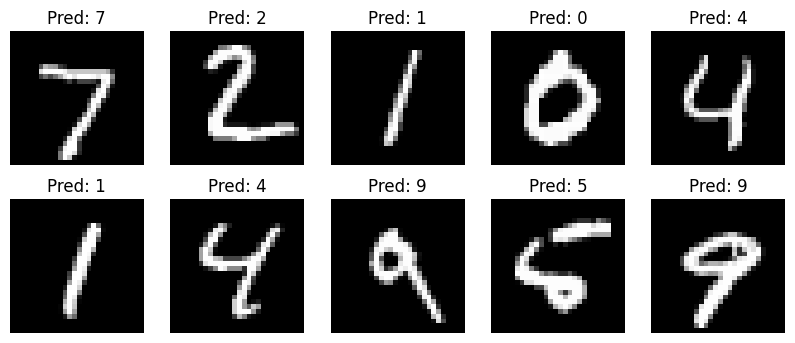

In [ ]:
plt.figure(figsize=(10,4))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X_test[i].reshape(28,28), cmap='gray')
    plt.title(f"Pred: {y_pred[i]}")
    plt.axis('off')

plt.show()